# CSE 327 P4

Team Members: Denny Li (del226@lehigh.edu)

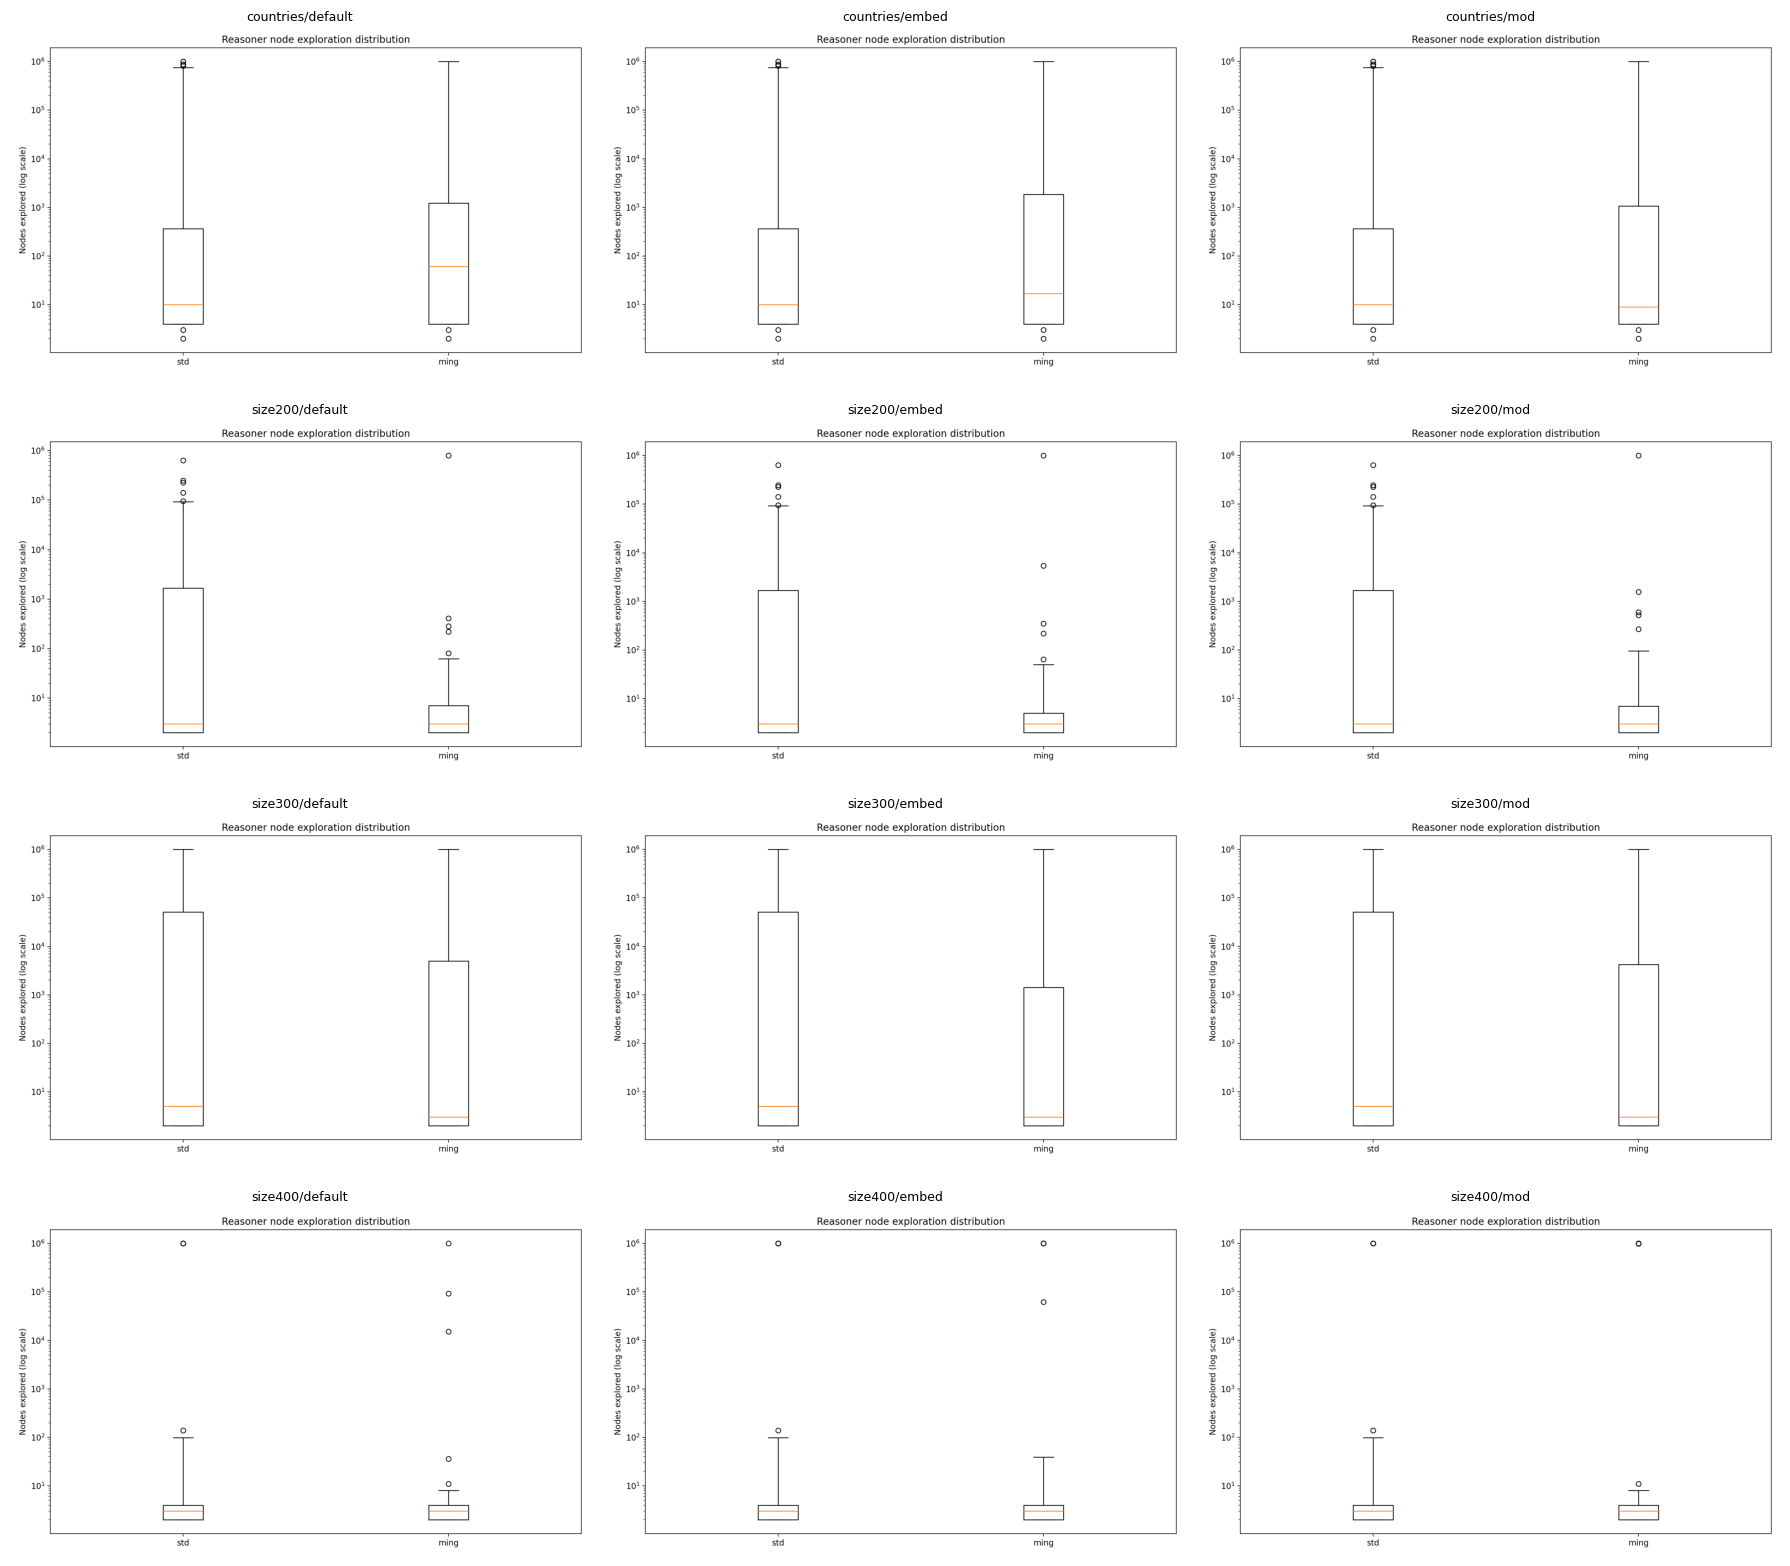

In [3]:
from pathlib import Path
import math
import matplotlib.pyplot as plt

image_paths = []
for kb in ["countries", "size200", "size300", "size400"]:
    for variant in ["default", "embed", "mod"]:
        image_paths.extend(
            sorted(Path(kb, variant).glob("reasoner_comparison-vs-default-*.png"))
        )

n = len(image_paths)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
axes = axes.flatten() if n > 1 else [axes]

for ax in axes[n:]:
    ax.axis("off")

for ax, img_path in zip(axes, image_paths):
    img = plt.imread(img_path)
    ax.imshow(img)
    ax.set_title(f"{img_path.parent}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

4.  Which performed better (`std` vs `ming`). Are there specific queries where one reasoner did better than the other (`countries/default` folder)?

While it is a close tie when it comes to the number of successes, `std` generated less median nodes compared to `ming`, at 10 vs 60.5, respectively. Overall, `ming` generated approx. 1600 more nodes on average compared to `std`.

Some of the hardest queries are those that require multiple conditions to be fulfilled and so the depth of the search tree is very large. For example: `fourBorderTrip(romania, C), sharesBorder(ukraine, C), fourBorderTrip(C, City), sameAlliance(City, south_africa), usesSameCurrency(croatia, City)`. 
While neither is able to prove a solution to the query, `std` is able to "fail" faster, generating 1068 nodes vs `ming` with 7063. `std` was better at ruling out hard queries quickly, since it explored fewer nodes and used less time before concluding that no proof was found. The total time for `std` is 170 seconds (~3 minutes) while `ming` is 2227 seconds (~37 minutes). 

Overall, `std` is more efficient in terms of node generation and time taken, while `ming` may find a solution in some cases where `std` fails, but at the cost of generating many more nodes and taking more time. I would rather use the standard reasoner.

6. For each random KB, compare the performance of `std` and `ming`. Which performed better (`size200`, `size300`, `size400`)?

- For `size200`, `ming` performed better overall. It explored fewer nodes on average than `std` (`7,965` vs `17,960`) and won on far more queries (`36` wins for `ming` vs `3` for `std`). All queries were solved by both reasoners, so the main difference was efficiency rather than success rate.

- For `size300`, `ming` also performed better overall. It explored fewer average nodes (`85,364` vs `142,350`) and won more queries (`37` vs `18`). There were a few queries where only one reasoner succeeded, and `ming` solved more of those than `std`.

- For `size400`, `ming` again performed better overall. It explored far fewer nodes on average (`11,084` vs `40,008`) and won more queries (`20` vs `2`). It also solved more of the queries that were uniquely successful for one reasoner.

Overall, `ming` performed better than `std` on all three random KBs: `size200`, `size300`, and `size400`. The biggest improvement was in average node count, which suggests the learned reasoner is much more efficient than the standard backward-chaining baseline on these random KBs.

However, I do believe that because the KB were generated procedurally, they may have certain patterns that `ming` is able to exploit, which may not be the case in real-world KBs (such as the `countries` KB). So while `ming` performs better on these random KBs, it may not necessarily generalize to all types of KBs.

7. Does increasing embedding size make it better or worse training loss? Does it improve or worsen test performance? Why? (`size200`, `size300`, `size400`)


Increasing the embedding size generally made almost no positive impact in the guided training loss, and the effect on test performance was mixed rather than absolutely better.

- For `size200`, increasing the embedding size to 75 made test performance worse overall for `ming`. The default size-50 run explored fewer average nodes than the larger embedding run (7,965 vs 10,066) and solved slightly more queries. So for this KB, the larger embedding did not help.

- For `size300`, increasing the embedding size helped. The size-75 run explored fewer average nodes than the size-50 run (76,338 vs 85,364) and also had slightly better success behavior. This is the one random KB where the larger embedding seems to have improved learned reasoning.

- For `size400`, increasing the embedding size hurt performance. The size-50 run was much better than the size-75 run in average nodes explored (11,084 vs 40,628), and it also had stronger overall behavior in the comparison.

- For `countries`, the larger embedding size also hurt performance. The size-75 run explored many more nodes on average than the default size-50 run (130,082 vs 70,071), so the increased embedding size did not help on this KB.

Overall, increasing embedding size did not consistently improve test performance. It helped on `size300`, but it hurt on `size200`, `size400`, and `countries`. The most likely reason is that larger embeddings give the model more capacity, but that extra capacity does not automatically translate into better guidance for reasoning. On some KBs it seems to help the model represent the structure better, while on others it makes the learned guidance less stable or less aligned with the query distribution.

9. Evaluate the results of changing the architecture of the network.

The modified architecture is not any better than the default neural network setup, and in this comparison it does not appear to be a clear improvement on any of the KBs.

- On `countries`, the modified architecture performed worse than the default learned model. It explored more nodes on average and had a weaker overall comparison against the default setup.

- On `size200`, the modified architecture was also worse than the default learned model. The default learned model explored fewer nodes on average and had slightly better success behavior.

- On `size300`, the modified architecture again underperformed the default learned model. It still beat `std`, but it did not beat the default learned architecture.

- On `size400`, the modified architecture was much worse than the default learned model. This was the biggest gap, with the default learned model clearly outperforming the modified one on average node count.

Overall, the new architecture does not seem to improve performance over the default size-50 network. If anything, it tends to hurt the learned reasoner’s efficiency, especially on the larger random KBs. The safest conclusion is that the a random architecture change with no deep knowledge on building neural networks did not help, and the original model was generally stronger.

10. Create a table that summarizes the results of the experiments.

In [7]:
import pandas as pd

df = pd.read_csv("reasoner_comparison_summary.csv")

# Make the columns a little more analysis-friendly.
df["learned_node_improvement_pct"] = (
    (df["std_mean_nodes"] - df["ming_mean_nodes"]) / df["std_mean_nodes"]
) * 100

df["learned_time_improvement_pct"] = (
    (df["std_total_time"] - df["ming_total_time"]) / df["std_total_time"]
) * 100

summary_df = (
    df[
        [
            "kb",
            "variant",
            "baseline_std_file",
            "ming_file",
            "std_mean_nodes",
            "ming_mean_nodes",
            "learned_node_improvement_pct",
            "std_total_time",
            "ming_total_time",
            "learned_time_improvement_pct",
            "std_wins",
            "ming_wins",
            "ties",
            "both_success",
            "std_only_success",
            "ming_only_success",
            "both_fail",
            "mean_node_delta_std_minus_ming",
            "total_time_delta_std_minus_ming",
        ]
    ]
    .sort_values(["kb", "variant"])
    .reset_index(drop=True)
)
display_df = summary_df.rename(
    columns={
        "kb": "KB",
        "variant": "Variant",
        "std_mean_nodes": "Std mean nodes",
        "ming_mean_nodes": "Ming mean nodes",
        "learned_node_improvement_pct": "Node improv %",
        "std_total_time": "Std time",
        "ming_total_time": "Ming time",
        "learned_time_improvement_pct": "Time improv %",
        "std_wins": "Std wins",
        "ming_wins": "Ming wins",
        "ties": "Ties",
        "both_success": "Both success",
        "std_only_success": "Std only success",
        "ming_only_success": "Ming only success",
        "both_fail": "Both fail",
    }
)

# Round only the columns that need it.
display_df["Std mean nodes"] = display_df["Std mean nodes"].round(0).astype(int)
display_df["Ming mean nodes"] = display_df["Ming mean nodes"].round(0).astype(int)
display_df["Node improv %"] = display_df["Node improv %"].round(1)

display_df["Std time"] = display_df["Std time"].round(2)
display_df["Ming time"] = display_df["Ming time"].round(2)
display_df["Time improv %"] = display_df["Time improv %"].round(1)

display_df["Std wins"] = display_df["Std wins"].astype(int)
display_df["Ming wins"] = display_df["Ming wins"].astype(int)
display_df["Ties"] = display_df["Ties"].astype(int)
display_df["Both success"] = display_df["Both success"].astype(int)
display_df["Std only success"] = display_df["Std only success"].astype(int)
display_df["Ming only success"] = display_df["Ming only success"].astype(int)
display_df["Both fail"] = display_df["Both fail"].astype(int)
display_df = display_df[
    [
        "KB",
        "Variant",
        "Std mean nodes",
        "Ming mean nodes",
        "Node improv %",
        "Std time",
        "Ming time",
        "Time improv %",
        "Std wins",
        "Ming wins",
        "Ties",
        "Both success",
        "Std only success",
        "Ming only success",
        "Both fail",
    ]
]

display_df

,KB,Variant,Std mean nodes,Ming mean nodes,Node improv %,Std time,Ming time,Time improv %,Std wins,Ming wins,Ties,Both success,Std only success,Ming only success,Both fail
0,countries,default,68487,70071,-2.3,169.69,2227.80,-1212.9,47,14,39,84,0,1,15
1,countries,embed,68487,130082,-89.9,169.69,5822.12,-3331.0,43,14,43,84,0,0,16
2,countries,mod,68487,80711,-17.8,169.69,2345.57,-1282.3,33,24,43,83,1,1,15
3,size200,default,17960,7965,55.6,55.12,85.59,-55.3,3,36,61,100,0,0,0
4,size200,embed,17960,10066,44.0,55.12,69.98,-27.0,7,35,58,99,1,0,0
5,size200,mod,17960,10038,44.1,55.12,76.21,-38.3,4,35,61,99,1,0,0
6,size300,default,142350,85364,40.0,1004.96,2191.44,-118.1,18,37,45,88,3,6,3
7,size300,embed,142350,76338,46.4,1004.96,2615.73,-160.3,18,38,44,86,5,8,1
8,size300,mod,142350,122334,14.1,1004.96,3856.52,-283.7,18,37,45,83,8,7,2
9,size400,default,40008,11084,72.3,330.71,228.63,30.9,2,20,78,95,1,4,0


11. Reflect on what you have learned through these experiments. Which versions of the learned model worked best? What sorts of differences do you see in performance across different KBs?


Using the relative improvement numbers, there is no single learned-model version that works best on every KB. The strongest model depends on the KB, and performance varies quite a bit across domains.

The learned model is clearly KB-dependent:
- For `countries`, none of the learned variants beat the standard reasoner, and the default learned model was the best of the learned versions, though still slightly worse than `std`.
- For `size200`, the default learned model worked best. It explored fewer nodes on average than the other learned variants and performed very well overall.
- For `size300`, the embed-size variant worked best. It explored fewer nodes on average than both the default learned model and the modified architecture.
- For `size400`, the default learned model was again best. The embed-size and modified versions were much weaker on this KB.

Other facts:
- Since the KBs are "randomly" generated, but done procedurally via an algorithm. That could result in patterns the model may be able to recognize and exploit.
- The `countries` KB is hard, in fact, it may require a larger embedding model to learn its relationships.
- The standard reasoner is best for its cost to performance ratio: it did not take that long to finish all 100 test queries, nor did it require an extensive amount of initial time, as it doesn't require training.

Overall, the experiments suggest that:
- The learned reasoner can be much better than standard backward chaining on some KBs, but it is not universally better.
- Increasing embedding size helps on some KBs, but doesn't always mean better performance.
- Modifying the architecture did not provide a consistent improvement without better knowledge on building good neural networks.
